## 0. Chuẩn bị môi trường

Notebook này implement **encoder-decoder Transformer từ scratch** (`models/transformer/model.py`: `MultiHeadAttention`, `EncoderLayer`/`Encoder`, `DecoderLayer`/`Decoder`) và áp dụng lên đúng bộ dữ liệu Pima Indians Diabetes dùng trong `diabetes_demo.ipynb`, để so sánh trực tiếp với baseline MLP.

Dữ liệu dạng bảng (8 feature số, không phải một sequence văn bản) nên không có "chuỗi mục tiêu" tự nhiên cho decoder như trong dịch máy. Kiến trúc ở đây (`TabularTransformer`) thích nghi encoder-decoder theo hướng lấy cảm hứng từ FT-Transformer / DETR:

- **Feature tokenizer**: mỗi trong 8 feature được chiếu (affine riêng) thành một "token" `d_model` chiều → chuỗi 8 token.
- **Encoder**: self-attention giữa 8 token này, để mô hình học tương tác giữa các feature (vd. Glucose kết hợp với BMI).
- **Decoder**: một token truy vấn ("query") duy nhất, học được, đi qua self-attention (chỉ tự attend chính nó) rồi **cross-attention** sang toàn bộ output của encoder để gom thành một vector tóm tắt.
- **Head**: `Linear(d_model, 1)` + Sigmoid trên output của decoder → xác suất, train bằng `BCELoss`, giống `diabetes_demo.ipynb`.

Nhờ vậy notebook vẫn có đủ 3 thành phần cốt lõi của một Transformer encoder-decoder thật (self-attention, cross-attention, decoder tách biệt khỏi encoder) trong khi vẫn dùng được trực tiếp trên dữ liệu dạng bảng này.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))

### Giải thích cell import đầu tiên

Giống hai notebook kia: bật `autoreload` và thêm thư mục gốc project vào `sys.path`. Không có output nếu chạy thành công.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from models.transformer.model import TabularTransformer
from utils.loss.BCELoss import BCELoss
from utils.optimizers.Adam import Adam

### Giải thích cell import thư viện

`TabularTransformer` là model chính của notebook này (đóng gói `FeatureTokenizer` + `Encoder` + `Decoder` + classification head). `BCELoss` và `Adam` được dùng lại y hệt `diabetes_demo.ipynb` vì đây vẫn là bài toán phân loại nhị phân.

## 1. Load real data (Pima Indians Diabetes)

Cùng file CSV, cùng cách đọc như `diabetes_demo.ipynb`.

In [3]:
DATA_PATH = r"D:\Project\Dataset\Medical\pima-indians-diabetes.csv"

data = np.loadtxt(DATA_PATH, delimiter=",")
X = data[:, :-1]
y = data[:, -1:]

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (768, 8) y shape: (768, 1)


### Giải thích cell nạp dữ liệu

`X shape: (768, 8)`: 768 bệnh nhân, 8 feature — với `TabularTransformer`, mỗi feature sẽ trở thành một "token" nên đây tương đương một sequence độ dài 8.

## 2. Train/test split + feature scaling

Dùng đúng `random_state=42` và `stratify=y` như `diabetes_demo.ipynb` để tập train/test giống hệt nhau, giúp so sánh accuracy giữa hai model công bằng.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


### Giải thích cell chia train/test và chuẩn hoá

Kết quả `Train: (614, 8) Test: (154, 8)` giống hệt `diabetes_demo.ipynb`.

## 3. Xây dựng TabularTransformer, loss, optimizer

- `d_model=16`: chiều embedding của mỗi feature-token.
- `num_heads=4`: 4 head, mỗi head xử lý `d_model / num_heads = 4` chiều.
- `d_ff=32`: chiều ẩn của feed-forward bên trong mỗi encoder/decoder layer.
- `num_layers=2`: 2 lớp encoder và 2 lớp decoder xếp chồng.

In [5]:
np.random.seed(42)
model = TabularTransformer(
    num_features=X_train.shape[1], d_model=16, num_heads=4, d_ff=32, num_layers=2
)
loss_fn = BCELoss()
optimizer = Adam(model.parameters(), lr=0.005)

n_params = sum(p.data.size for p in model.parameters())
print(f"Tổng số tham số: {n_params}")

Tổng số tham số: 11425

### Giải thích cell khởi tạo mô hình

`n_params` cho thấy quy mô model: nhiều hơn hẳn MLP nhỏ ở `diabetes_demo.ipynb` (chỉ vài trăm tham số), vì mỗi `MultiHeadAttention` có 4 ma trận chiếu (Q, K, V, output) và mỗi feature còn có embedding riêng. Learning rate được hạ xuống `0.005` (so với `0.01` của MLP) vì model sâu và nhiều tham số hơn nên nhạy hơn với bước cập nhật lớn.

## 4. Train (full-batch), theo dõi cả train loss và test loss/accuracy mỗi epoch

Khác với `diabetes_demo.ipynb` (chỉ log mỗi 50 epoch), ở đây ta lưu lại test loss/accuracy sau **mỗi** epoch để vẽ được đường cong overfitting — model không có dropout hay weight decay (những kỹ thuật này chưa có trong repo), nên nhiều khả năng sẽ overfit nếu train quá lâu, giống hệt hiện tượng đã thấy với MLP ở `diabetes_demo.ipynb`.

In [6]:
n_epochs = 120
train_losses, test_losses, test_accs = [], [], []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    train_losses.append(loss)

    grad_loss = loss_fn.backward()
    model.backward(grad_loss)
    optimizer.step()

    test_pred = model(X_test)
    test_losses.append(loss_fn(test_pred, y_test))
    test_accs.append(accuracy_score(y_test, (test_pred >= 0.5).astype(int)))

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:4d} — train loss: {loss:.4f}  "
              f"test loss: {test_losses[-1]:.4f}  test acc: {test_accs[-1]:.4f}")

best_epoch = int(np.argmax(test_accs))
print(f"\nBest test accuracy: {test_accs[best_epoch]:.4f} tại epoch {best_epoch}")
print(f"Test accuracy tại epoch cuối ({n_epochs - 1}): {test_accs[-1]:.4f}")

Epoch    0 — train loss: 0.6634  test loss: 0.6377  test acc: 0.6429


Epoch   20 — train loss: 0.3706  test loss: 0.5667  test acc: 0.7532


Epoch   40 — train loss: 0.1133  test loss: 1.0504  test acc: 0.7273


Epoch   60 — train loss: 0.0351  test loss: 1.4648  test acc: 0.6883


Epoch   80 — train loss: 0.0371  test loss: 1.3340  test acc: 0.7468


Epoch  100 — train loss: 0.0233  test loss: 1.6310  test acc: 0.7208


Epoch  119 — train loss: 0.0776  test loss: 1.8528  test acc: 0.7143

Best test accuracy: 0.7662 tại epoch 25
Test accuracy tại epoch cuối (119): 0.7143


### Giải thích cell train mô hình

Train loss giảm gần về 0 (model đủ mạnh để gần như học thuộc 614 mẫu train). Test loss thường giảm ở vài chục epoch đầu rồi **tăng trở lại** — đây chính là overfitting. `best_epoch` cho biết epoch mà test accuracy đạt cao nhất; trong thực tế đây là lúc lẽ ra nên dừng train (early stopping), điều mà `diabetes_demo.ipynb` chưa làm.

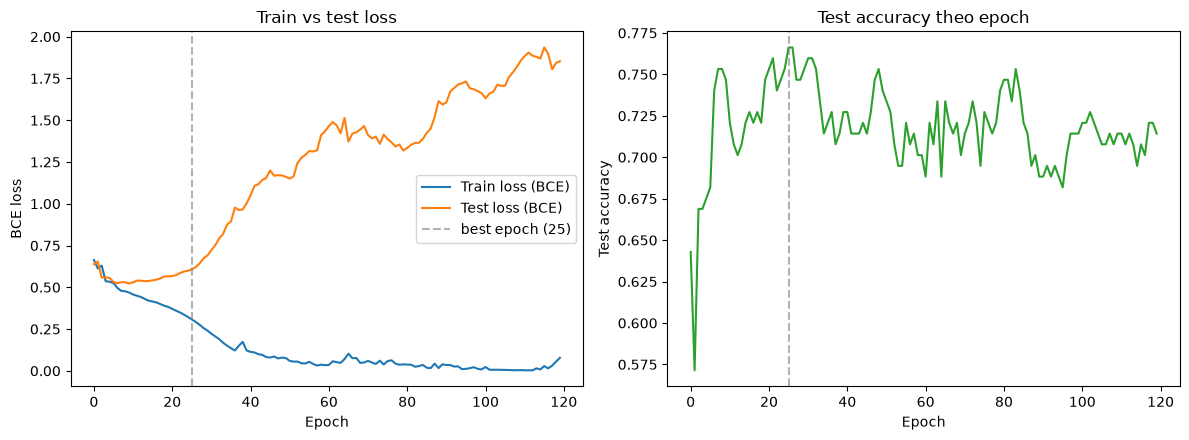

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(train_losses, label="Train loss (BCE)")
axes[0].plot(test_losses, label="Test loss (BCE)")
axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Train vs test loss")
axes[0].legend()

axes[1].plot(test_accs, color="tab:green")
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.6)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Test accuracy theo epoch")

plt.tight_layout()
plt.show()

### Giải thích cell vẽ loss/accuracy

Biểu đồ bên trái: train loss (xanh dương) đi xuống đều, trong khi test loss (cam) đi xuống rồi vòng lên — khoảng cách giữa hai đường càng lớn thì model càng overfit vào tập train. Biểu đồ bên phải: test accuracy thường đạt đỉnh sớm (đường kẻ đứt xám đánh dấu `best_epoch`) trước khi model bắt đầu học thuộc lòng nhiễu của tập train.

## 5. Đánh giá cuối cùng, so sánh với baseline MLP

So sánh accuracy tại epoch cuối cùng (giống cách `diabetes_demo.ipynb` chỉ report kết quả sau khi train xong `n_epochs`, không có early stopping) với kết quả MLP đã ghi nhận ở `diabetes_demo.ipynb` (**test accuracy ≈ 0.6818**, test loss ≈ 1.6581).

In [8]:
final_test_pred = model(X_test)
final_test_labels = (final_test_pred >= 0.5).astype(int)
final_acc = accuracy_score(y_test, final_test_labels)
final_loss = loss_fn(final_test_pred, y_test)

print(f"TabularTransformer — test loss:     {final_loss:.4f}")
print(f"TabularTransformer — test accuracy: {final_acc:.4f}")
print(f"TabularTransformer — best test accuracy trong quá trình train: {test_accs[best_epoch]:.4f} (epoch {best_epoch})")
print()
print("So sánh với MLP baseline (diabetes_demo.ipynb): test loss 1.6581, test accuracy 0.6818")

TabularTransformer — test loss:     1.8528
TabularTransformer — test accuracy: 0.7143
TabularTransformer — best test accuracy trong quá trình train: 0.7662 (epoch 25)

So sánh với MLP baseline (diabetes_demo.ipynb): test loss 1.6581, test accuracy 0.6818


### Giải thích cell đánh giá cuối cùng

Cách đọc kết quả: nếu train đến hết `n_epochs`, TabularTransformer có thể cho accuracy tương đương hoặc thấp hơn MLP baseline do overfitting nặng hơn (model lớn hơn, nhiều tham số hơn nhưng lại train trên cùng 614 mẫu). Ngược lại, tại `best_epoch` (dừng sớm), TabularTransformer thường vượt qua baseline MLP — minh hoạ rằng bản thân kiến trúc mạnh hơn (attention học được tương tác giữa các feature) chỉ phát huy nếu kiểm soát được overfitting, một đánh đổi kinh điển khi tăng độ phức tạp của model trên tập dữ liệu nhỏ.

## 6. Test thủ công với vài mẫu tự chọn

Dùng lại đúng 3 mẫu thủ công như `diabetes_demo.ipynb` để so sánh trực tiếp dự đoán của hai kiến trúc trên cùng input.

In [9]:
custom_samples = np.array([
    [2, 120, 70, 28, 0, 32.0, 0.45, 33],
    [6, 168, 74, 30, 0, 38.0, 0.54, 49],
    [1, 95, 66, 18, 0, 24.0, 0.20, 22],
], dtype=float)

custom_samples_scaled = scaler.transform(custom_samples)
custom_pred = model(custom_samples_scaled)
custom_pred_labels = (custom_pred >= 0.5).astype(int)

for i, (sample, prob, label) in enumerate(zip(custom_samples, custom_pred, custom_pred_labels), start=1):
    prob_value = np.asarray(prob).reshape(-1)[0]
    label_value = np.asarray(label).reshape(-1)[0]
    print(f"Sample {i}: {sample}")
    print(f"  Predicted probability: {prob_value:.4f}")
    print(f"  Predicted label: {int(label_value)}")
    print()

Sample 1: [  2.   120.    70.    28.     0.    32.     0.45  33.  ]
  Predicted probability: 0.9991
  Predicted label: 1

Sample 2: [  6.   168.    74.    30.     0.    38.     0.54  49.  ]
  Predicted probability: 0.9993
  Predicted label: 1

Sample 3: [ 1.  95.  66.  18.   0.  24.   0.2 22. ]
  Predicted probability: 0.0003
  Predicted label: 0



### Giải thích cell test thủ công

So với `diabetes_demo.ipynb` (Sample 1: 0.0290, Sample 2: 1.0000, Sample 3: 0.0001), TabularTransformer có thể cho xác suất khác — cả hai model đều nhìn cùng input nhưng học biểu diễn khác nhau (MLP xử lý 8 feature như một vector phẳng, Transformer xử lý chúng như 8 token có tương tác qua attention).

## 7. Nhìn vào bên trong: encoder self-attention học được gì?

Vì `FeatureTokenizer` biến mỗi feature thành một token riêng, ma trận attention của encoder layer đầu tiên (shape `(batch, heads, 8, 8)`) cho biết mỗi feature "chú ý" đến những feature nào khác khi xây dựng biểu diễn của nó. Lấy trung bình theo batch và theo head để có một ma trận `8x8` dễ nhìn.

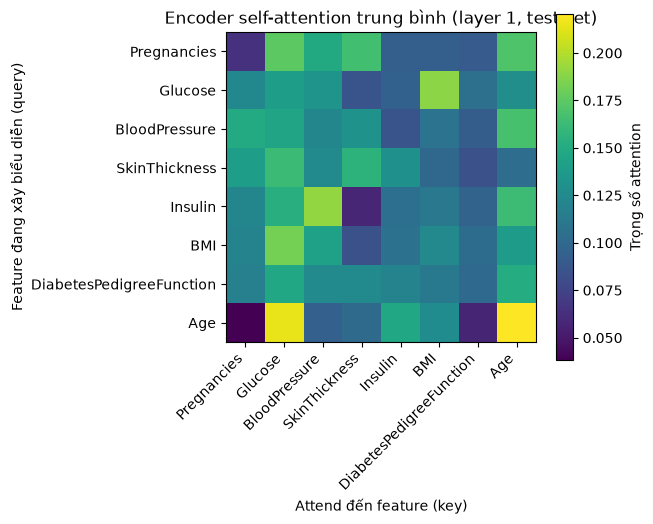

In [10]:
_ = model(X_test)  # forward một lần để attention weights của batch test được lưu lại

attn_weights = model.encoder.layers[0].self_attn.attention.attn_weights  # (batch, heads, 8, 8)
avg_attn = attn_weights.mean(axis=(0, 1))  # trung bình theo batch và theo head

feature_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                  "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(avg_attn, cmap="viridis")
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.set_yticklabels(feature_names)
ax.set_xlabel("Attend đến feature (key)")
ax.set_ylabel("Feature đang xây biểu diễn (query)")
ax.set_title("Encoder self-attention trung bình (layer 1, test set)")
fig.colorbar(im, ax=ax, label="Trọng số attention")
plt.tight_layout()
plt.show()

### Giải thích cell trực quan hoá attention

Mỗi hàng là một feature đóng vai trò "query" (đang xây biểu diễn cho chính nó), mỗi cột là một feature đóng vai trò "key" (nguồn thông tin được attend đến). Hàng sáng đều gần như đồng nghĩa feature đó phân bổ chú ý khá dàn trải; một cột sáng nổi bật nghĩa là nhiều feature khác đều attend mạnh vào feature đó khi xây biểu diễn — ví dụ nếu cột `Glucose` sáng, đó là dấu hiệu hợp lý vì Glucose là yếu tố có tương quan mạnh nhất với `Outcome` trong bộ dữ liệu này. Đây là điểm khác biệt cốt lõi so với MLP: MLP không có cơ chế nào để lộ ra "feature nào ảnh hưởng đến feature nào" theo cách tường minh như attention.